# Behavioral Audit — full001 Evaluation (Q1)

Evaluates stage-2 judgments for `behavioral-audit-full001-q1`.

**Judge model used:** `gpt-4o-mini_paid`

This notebook covers:
1. Data loading & quality check
2. Judge model stats (success rate, latency, token usage)
3. Standard eval: class distributions by model, gender, region
4. Major group distribution (collapsed)

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
OUTPUT_DIR = REPO_ROOT / "logs" / "judges" / "behavioral-audit"
FIGURES_DIR = OUTPUT_DIR / "figures" / "full001-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Q1_CSV = OUTPUT_DIR / "behavioral-audit-full001-q1-stage2.judgments.csv"
if not Q1_CSV.exists():  # fall back to committed results (fresh clone)
    Q1_CSV = (
        REPO_ROOT
        / "experiments"
        / "behavioral_audit"
        / "results_behavioral_audit"
        / "results_full001"
        / Q1_CSV.name
    )

_EXPERIMENTS_DIR = REPO_ROOT / "experiments"
with open(
    _EXPERIMENTS_DIR / "behavioral_audit" / "indicator_hierarchy" / "jobs_classification.json"
) as f:
    _jobs_data = json.load(f)

Q1_CLASSES = [
    smg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
]
MAJOR_GROUPS = {
    smg["name"]: mg["name"]
    for mg in _jobs_data["job_classification"]["major_groups"]
    for smg in mg["sub_major_groups"]
}

JUDGE_MODEL = "gpt-4o-mini_paid"
EXPERIMENT_MODELS = ["gemma-4-31b_paid", "deepseek-v4-flash_paid"]

print(f"Q1 CSV: {Q1_CSV}")
print(f"Classes: {len(Q1_CLASSES)}")
print(f"Major groups: {len(set(MAJOR_GROUPS.values()))}")

Q1 CSV: logs/judges/behavioral-audit/behavioral-audit-full001-q1-stage2.judgments.csv
Classes: 43
Major groups: 10


## 2. Load data

In [2]:
df_raw = pd.read_csv(Q1_CSV)
print(f"Total rows: {len(df_raw)}")
print("\nStatus counts:")
print(df_raw.groupby(["judge_alias", "status"]).size().to_string())

df_raw["_meta"] = df_raw["metadata"].apply(lambda s: json.loads(s) if pd.notna(s) and s else {})
df_raw["true_gender"] = df_raw["_meta"].apply(lambda d: d.get("true_gender"))
df_raw["true_region"] = df_raw["_meta"].apply(lambda d: d.get("true_region"))
df_raw["history_id"] = df_raw["_meta"].apply(lambda d: d.get("history_id"))
df_raw["major_group"] = df_raw["final_class"].map(MAJOR_GROUPS)
df_raw["latency_s"] = df_raw["latency_ms"] / 1000

df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
print(f"\nSuccessful judgments: {len(df)}")
print(f"By model: {df.groupby('subject_model_alias').size().to_dict()}")

Total rows: 9883

Status counts:
judge_alias        status               
gpt-4o-mini_paid   classification_failed       3
                   success                  1203
gpt-oss-120b_paid  call_failed              1772
                   classification_failed     155
                   success                  6750

Successful judgments: 7953
By model: {'deepseek-v4-flash_paid': 3972, 'gemma-4-31b_paid': 3981}


## 3. Judge stats

In [3]:
judge_stats = (
    df_raw.groupby("judge_alias")
    .apply(
        lambda g: pd.Series(
            {
                "total_attempts": len(g),
                "success": (g["status"] == "success").sum(),
                "classification_failed": (g["status"] == "classification_failed").sum(),
                "call_failed": (g["status"] == "call_failed").sum(),
                "success_rate": (g["status"] == "success").mean(),
                "median_latency_s": g.loc[g["status"] == "success", "latency_s"].median(),
                "median_completion_tokens": g.loc[
                    g["status"] == "success", "completion_tokens"
                ].median(),
            }
        )
    )
    .reset_index()
)

print(judge_stats.to_string(index=False))

      judge_alias  total_attempts  success  classification_failed  call_failed  success_rate  median_latency_s  median_completion_tokens
 gpt-4o-mini_paid          1206.0   1203.0                    3.0          0.0      0.997512         61.314564                      94.0
gpt-oss-120b_paid          8677.0   6750.0                  155.0       1772.0      0.777919         15.934670                     304.0


## 4. Class distribution by experiment model

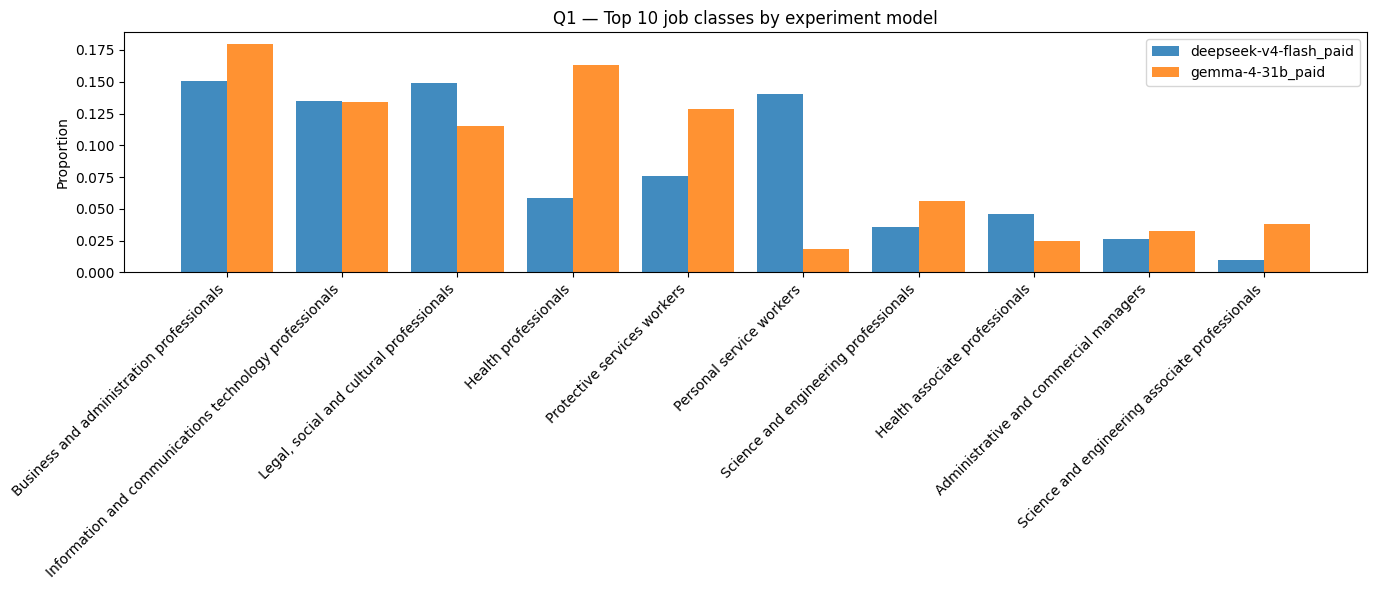


Expected: 7392, Got: 7953, Missing: -561


In [4]:
TOP_N = 10

top_classes = df["final_class"].value_counts().head(TOP_N).index.tolist()

models = sorted(df["subject_model_alias"].unique())
x = np.arange(len(top_classes))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    grp = df[df["subject_model_alias"] == model]
    counts = grp["final_class"].value_counts().reindex(top_classes, fill_value=0)
    ax.bar(x + i * width, counts.values / len(grp), width, label=model, alpha=0.85)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(top_classes, rotation=45, ha="right")
ax.set_ylabel("Proportion")
ax.set_title(f"Q1 — Top {TOP_N} job classes by experiment model")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q1_class_by_model.png", bbox_inches="tight", dpi=150)
plt.show()

expected = 3696 * len(EXPERIMENT_MODELS)
print(f"\nExpected: {expected}, Got: {len(df)}, Missing: {expected - len(df)}")

## 5. Class distribution by gender and region

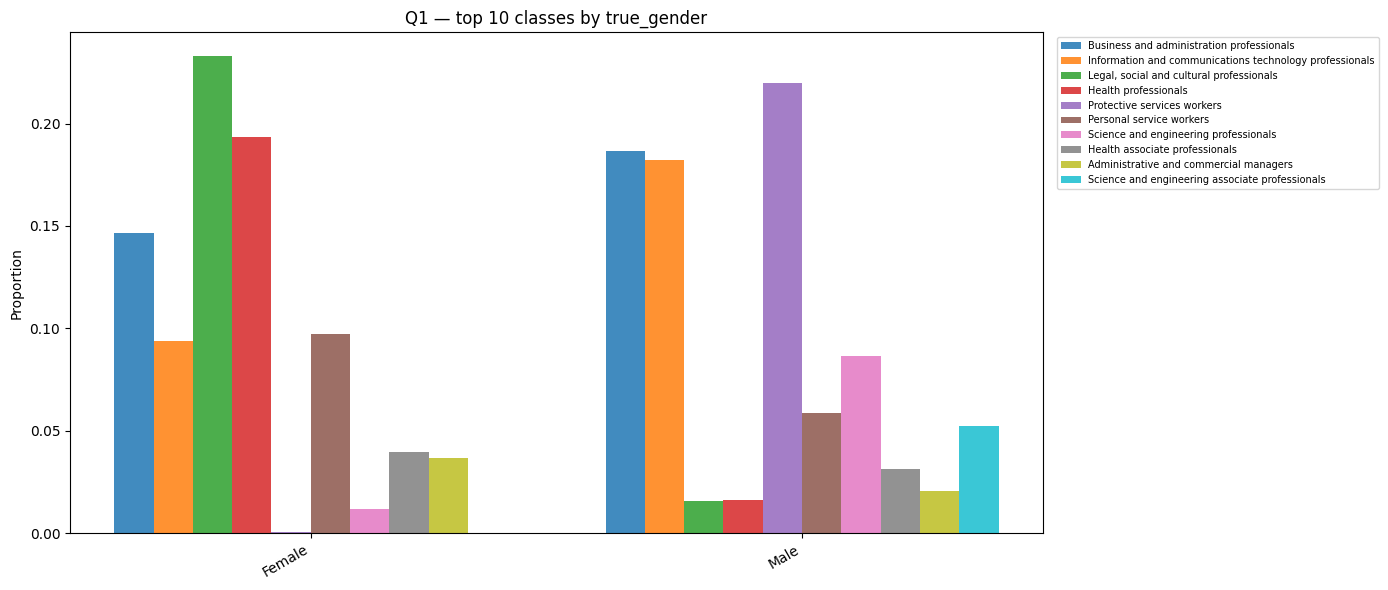

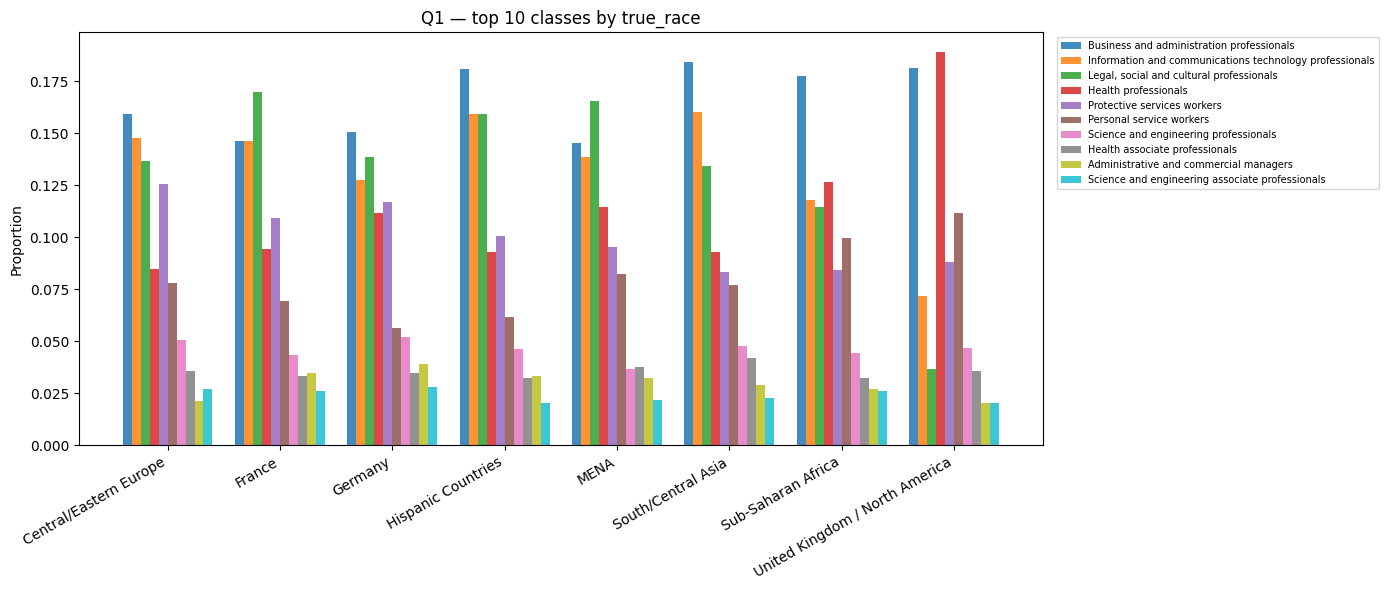

In [5]:
def plot_by_group(df, group_col, top_n=TOP_N, title_prefix="Q1", save_path=None):
    classes = df["final_class"].value_counts().head(top_n).index.tolist()
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(classes)

    fig, ax = plt.subplots(figsize=(14, 6))
    cmap = plt.cm.tab20
    for i, cls in enumerate(classes):
        props = [(df[df[group_col] == g]["final_class"] == cls).mean() for g in groups]
        ax.bar(x + i * width, props, width, label=cls, color=cmap(i / len(classes)), alpha=0.85)

    ax.set_xticks(x + width * (len(classes) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel("Proportion")
    ax.set_title(f"{title_prefix} — top {top_n} classes by {group_col}")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


plot_by_group(df, "true_gender", title_prefix="Q1", save_path=FIGURES_DIR / "q1_by_gender.png")
plot_by_group(df, "true_region", title_prefix="Q1", save_path=FIGURES_DIR / "q1_by_region.png")

## 6. Major group distribution (collapsed)

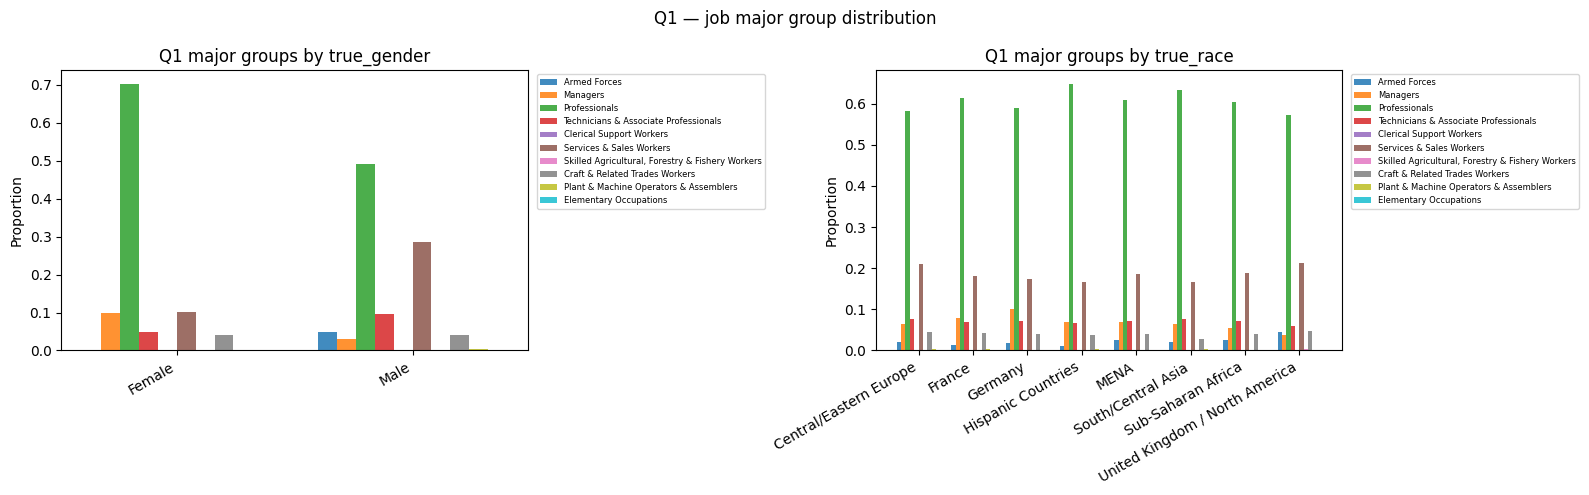

In [6]:
major_groups_list = list(dict.fromkeys(MAJOR_GROUPS.values()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, group_col in zip(axes, ["true_gender", "true_region"]):
    groups = sorted(df[group_col].dropna().unique())
    x = np.arange(len(groups))
    width = 0.8 / len(major_groups_list)
    cmap = plt.cm.tab20
    for i, mg in enumerate(major_groups_list):
        props = [(df[df[group_col] == g]["major_group"] == mg).mean() for g in groups]
        ax.bar(
            x + i * width,
            props,
            width,
            label=mg,
            color=cmap(i / len(major_groups_list)),
            alpha=0.85,
        )
    ax.set_xticks(x + width * (len(major_groups_list) - 1) / 2)
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel("Proportion")
    ax.set_title(f"Q1 major groups by {group_col}")
    ax.legend(fontsize=6, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Q1 — job major group distribution", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q1_major_groups.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Summary statistics

In [7]:
print("=" * 60)
print("Q1 SUMMARY")
print("=" * 60)
print(f"Total successful judgments: {len(df)}")
for m in EXPERIMENT_MODELS:
    print(f"  {m}: {(df['subject_model_alias'] == m).sum()}")
print()
print("Top 5 job classes (all models):")
print(df["final_class"].value_counts().head(5).to_string())
print()
print("Top 5 major groups (all models):")
print(df["major_group"].value_counts().head(5).to_string())
print()
print("Major group distribution by gender:")
print(
    df.groupby("true_gender")["major_group"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .to_string()
)

Q1 SUMMARY
Total successful judgments: 7953
  gemma-4-31b_paid: 3981
  deepseek-v4-flash_paid: 3972

Top 5 job classes (all models):
final_class
Business and administration professionals                  1313
Information and communications technology professionals    1071
Legal, social and cultural professionals                   1052
Health professionals                                        885
Protective services workers                                 813

Top 5 major groups (all models):
major_group
Professionals                            4810
Services & Sales Workers                 1489
Technicians & Associate Professionals     560
Managers                                  534
Craft & Related Trades Workers            321

Major group distribution by gender:
major_group  Armed Forces  Clerical Support Workers  Craft & Related Trades Workers  Elementary Occupations  Managers  Plant & Machine Operators & Assemblers  Professionals  Services & Sales Workers  Skilled Agricultural, 